# Simple Line Plots

Perhaps the simplest of all plots is the visualization of a single function $y = f(x)$.
Here we will take a first look at creating a simple plot of this type.
As in all the following chapters, we'll start by setting up the notebook for plotting and  importing the packages we will use:

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid') # seaborn-whitegrid 已被移除
import numpy as np

For all Matplotlib plots, we start by creating a figure and axes.
In their simplest form, this can be done as follows (see the following figure):

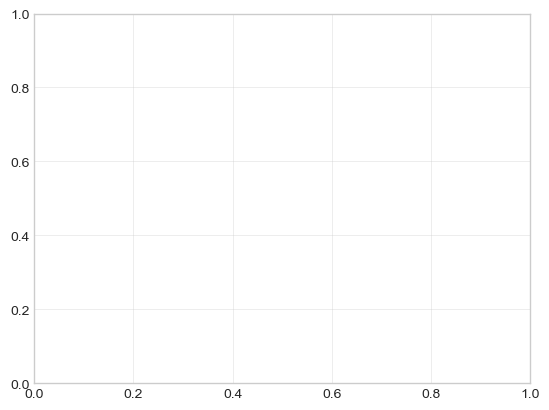

In [2]:
fig = plt.figure()
ax = plt.axes()
# 等价于 fig, ax = plt.subplots()

In Matplotlib, the *figure* (an instance of the class `plt.Figure`) can be thought of as a single container that contains all the objects representing axes, graphics, text, and labels.
The *axes* (an instance of the class `plt.Axes`) is what we see above: a bounding box with ticks, grids, and labels, which will eventually contain the plot elements that make up our visualization.
Throughout this part of the book, I'll commonly use the variable name `fig` to refer to a figure instance and `ax` to refer to an axes instance or group of axes instances.

Once we have created an axes, we can use the `ax.plot` method to plot some data. Let's start with a simple sinusoid, as shown in the following figure:

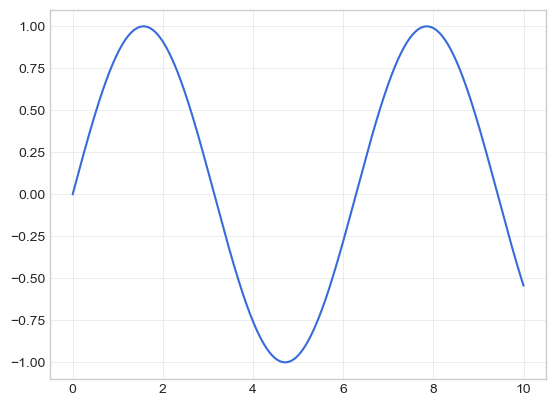

In [3]:
fig = plt.figure()
ax = plt.axes()
# ax 是一个坐标系对象，通过 ax 调用方法画图
# 同理，用画布对象 fig 调用方法可以调节画布大小，标题，颜色，分辨率以及保存画布
x = np.linspace(0, 10, 1000)
ax.plot(x, np.sin(x)); # 注意末尾分号，抑制了从输出中显示图形的文本表示

Note that the semicolon at the end of the last line is intentional: it suppresses the textual representation of the plot from the output.

Alternatively, we can use the PyLab interface and let the figure and axes be created for us in the background
(see [Two Interfaces for the Price of One](04.00-Introduction-To-Matplotlib.ipynb#Two-Interfaces-for-the-Price-of-One) for a discussion of these two interfaces); as the following figure shows, the result is the same:

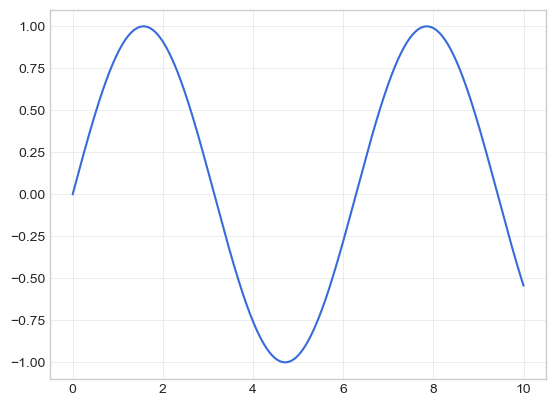

In [4]:
plt.plot(x, np.sin(x)) # 无分号对比

If we want to create a single figure with multiple lines (see the following figure), we can simply call the `plot` function multiple times:

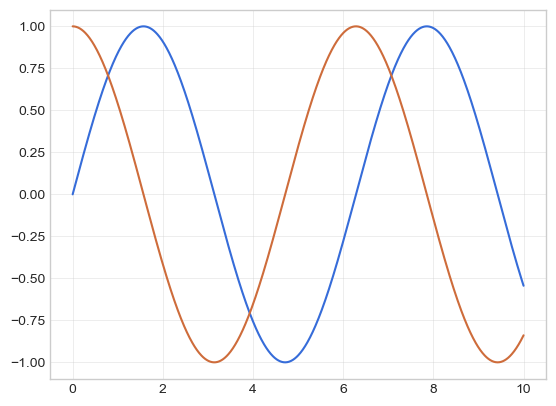

In [5]:
plt.plot(x, np.sin(x))
plt.plot(x, np.cos(x));

That's all there is to plotting simple functions in Matplotlib!
We'll now dive into some more details about how to control the appearance of the axes and lines.

## Adjusting the Plot: Line Colors and Styles

The first adjustment you might wish to make to a plot is to control the line colors and styles.
The `plt.plot` function takes additional arguments that can be used to specify these.
To adjust the color, you can use the `color` keyword, which accepts a string argument representing virtually any imaginable color.
The color can be specified in a variety of ways; see the following figure for the output of the following examples:

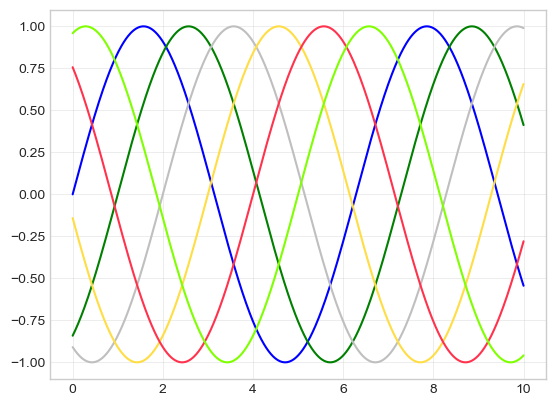

In [6]:
plt.plot(x, np.sin(x - 0), color='blue')        # specify color by name
plt.plot(x, np.sin(x - 1), color='g')           # short color code (rgbcmyk) 用首字母仅限于这8个
plt.plot(x, np.sin(x - 2), color='0.75')        # grayscale between 0 and 1
plt.plot(x, np.sin(x - 3), color='#FFDD44')     # hex code (RRGGBB, 00 to FF)
plt.plot(x, np.sin(x - 4), color=(1.0,0.2,0.3)) # RGB tuple, values 0 to 1
plt.plot(x, np.sin(x - 5), color='chartreuse'); # HTML color names supported

If no color is specified, Matplotlib will automatically cycle through a set of default colors for multiple lines.

Similarly, the line style can be adjusted using the `linestyle` keyword (see the following figure):

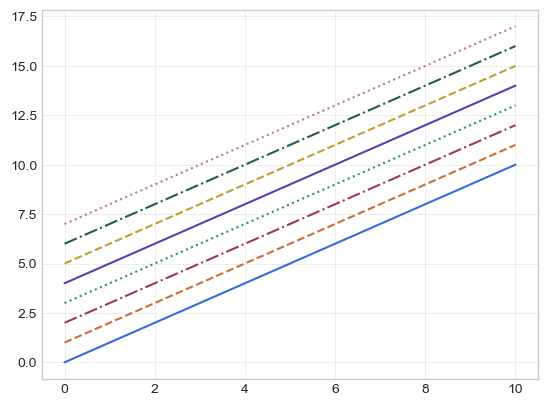

In [7]:
plt.plot(x, x + 0, linestyle='solid')
plt.plot(x, x + 1, linestyle='dashed')
plt.plot(x, x + 2, linestyle='dashdot')
plt.plot(x, x + 3, linestyle='dotted');

# For short, you can use the following codes:
plt.plot(x, x + 4, linestyle='-')  # solid 实线
plt.plot(x, x + 5, linestyle='--') # dashed 虚线
plt.plot(x, x + 6, linestyle='-.') # dashdot 点划线
plt.plot(x, x + 7, linestyle=':');  # dotted 点线

Though it may be less clear to someone reading your code, you can save some keystrokes by combining these `linestyle` and `color` codes into a single non-keyword argument to the `plt.plot` function; the following figure shows the result:

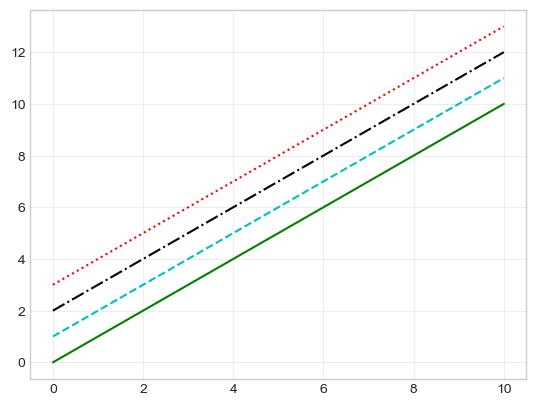

In [8]:
plt.plot(x, x + 0, '-g')   # solid green
plt.plot(x, x + 1, '--c')  # dashed cyan
plt.plot(x, x + 2, '-.k')  # dashdot black
plt.plot(x, x + 3, 'r:');  # dotted red
# 对于组合（线型，颜色等）的顺序没有要求

These single-character color codes reflect the standard abbreviations in the RGB (Red/Green/Blue) and CMYK (Cyan/Magenta/Yellow/blacK) color systems, commonly used for digital color graphics.

There are many other keyword arguments that can be used to fine-tune the appearance of the plot; for details, read through the docstring of the `plt.plot` function using IPython's help tools (see [Help and Documentation in IPython](01.01-Help-And-Documentation.ipynb)).

## Adjusting the Plot: Axes Limits

Matplotlib does a decent job of choosing default axes limits for your plot, but sometimes it's nice to have finer control.
The most basic way to adjust the limits is to use the `plt.xlim` and `plt.ylim` functions (see the following figure):

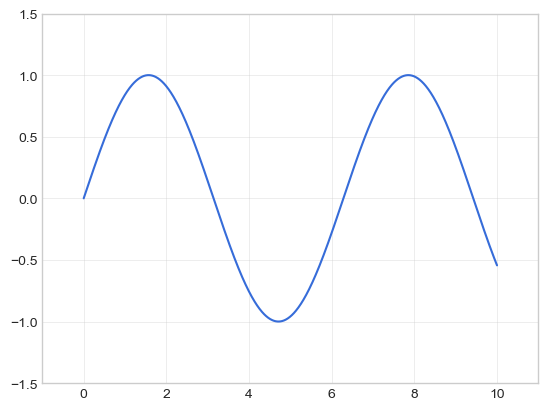

In [9]:
plt.plot(x, np.sin(x))

plt.xlim(-1, 11)
plt.ylim(-1.5, 1.5);
# 设置显示范围

If for some reason you'd like either axis to be displayed in reverse, you can simply reverse the order of the arguments (see the following figure):

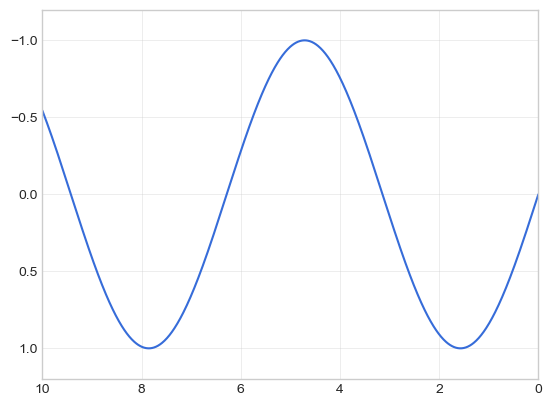

In [10]:
plt.plot(x, np.sin(x))

plt.xlim(10, 0)
plt.ylim(1.2, -1.2);
# 将轴倒置

A useful related method is `plt.axis` (note here the potential confusion between *axes* with an *e*, and *axis* with an *i*), which allows more qualitative specifications of axis limits. For example, you can automatically tighten the bounds around the current content, as shown in the following figure:

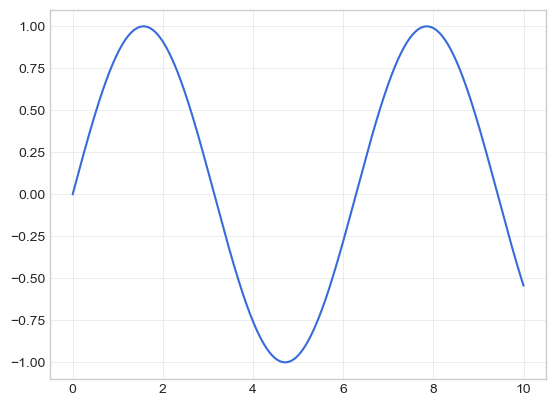

In [11]:
plt.plot(x, np.sin(x))
plt.axis('tight');
# 'auto'	自动缩放（默认）
# 'equal'	x/y 轴单位长度相等（圆形不会被压扁）
# 'scaled'	等比例但不自动缩放
# 'tight'	缩到刚好包裹数据
# 'square'	坐标轴区域为正方形
# 'off'	隐藏坐标轴

Or you can specify that you want an equal axis ratio, such that one unit in `x` is visually equivalent to one unit in `y`, as seen in the following figure:

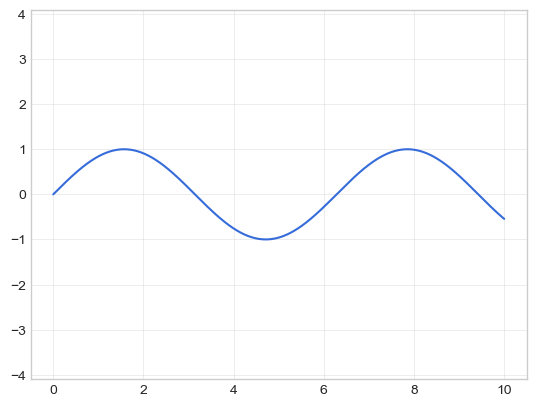

In [12]:
plt.plot(x, np.sin(x))
plt.axis('equal');

Other axis options include `'on'`, `'off'`, `'square'`, `'image'`, and more. For more information on these, refer to the `plt.axis` docstring.

## Labeling Plots

As the last piece of this chapter, we'll briefly look at the labeling of plots: titles, axis labels, and simple legends.
Titles and axis labels are the simplest such labels—there are methods that can be used to quickly set them (see the following figure):

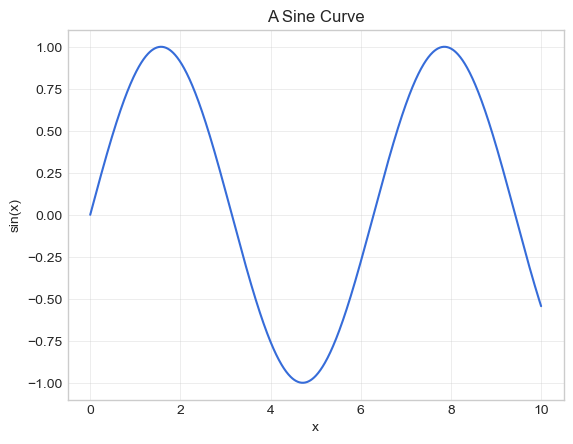

In [13]:
plt.plot(x, np.sin(x))
plt.title("A Sine Curve")
plt.xlabel("x")
plt.ylabel("sin(x)");

The position, size, and style of these labels can be adjusted using optional arguments to the functions, described in the docstrings.

When multiple lines are being shown within a single axes, it can be useful to create a plot legend that labels each line type.
Again, Matplotlib has a built-in way of quickly creating such a legend; it is done via the (you guessed it) `plt.legend` method.
Though there are several valid ways of using this, I find it easiest to specify the label of each line using the `label` keyword of the `plot` function (see the following figure):

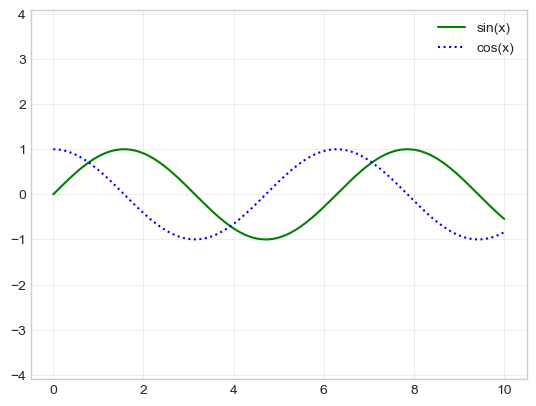

In [14]:
plt.plot(x, np.sin(x), '-g', label='sin(x)')
plt.plot(x, np.cos(x), ':b', label='cos(x)')
plt.axis('equal')

plt.legend(); # 显示图例(label)

As you can see, the `plt.legend` function keeps track of the line style and color, and matches these with the correct label.
More information on specifying and formatting plot legends can be found in the `plt.legend` docstring; additionally, we will cover some more advanced legend options in [Customizing Plot Legends](04.06-Customizing-Legends.ipynb).

## Matplotlib Gotchas

While most `plt` functions translate directly to `ax` methods (`plt.plot` → `ax.plot`, `plt.legend` → `ax.legend`, etc.), this is not the case for all commands.
In particular, functions to set limits, labels, and titles are slightly modified.
For transitioning between MATLAB-style functions and object-oriented methods, make the following changes:

- `plt.xlabel`  → `ax.set_xlabel`
- `plt.ylabel` → `ax.set_ylabel`
- `plt.xlim`  → `ax.set_xlim`
- `plt.ylim` → `ax.set_ylim`
- `plt.title` → `ax.set_title`

In the object-oriented interface to plotting, rather than calling these functions individually, it is often more convenient to use the `ax.set` method to set all these properties at once (see the following figure):

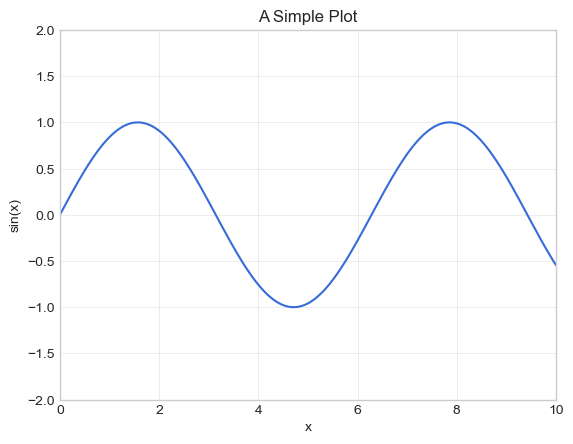

In [15]:
ax = plt.axes()
# 可以穿入参数 e.g. ax = plt.axes('221') 等价于 plt.subplot(2, 2, 1)
ax.plot(x, np.sin(x))
ax.set(xlim=(0, 10), ylim=(-2, 2),
       xlabel='x', ylabel='sin(x)',
       title='A Simple Plot');